In [ ]:
import os
os.environ["JAVA_HOME"] = r"C:\Users\hp\AppData\Local\Programs\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PYSPARK_PYTHON"] = r"C:\Users\hp\anaconda3\envs\pyspark_env\python.exe"

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("05 - Visualization") \
    .config("spark.driver.memory", "2g") \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()

df = spark.read.csv(
    r"C:\Users\hp\BIGDATAPROJECT\data\Tweets.csv",
    header=True, inferSchema=True
).dropna(subset=["airline_sentiment","airline","text"])

df.createOrReplaceTempView("tweets")
print(" Ready for visualization!")

 Ready for visualization!


#Chart 1: Sentiment Pie Chart

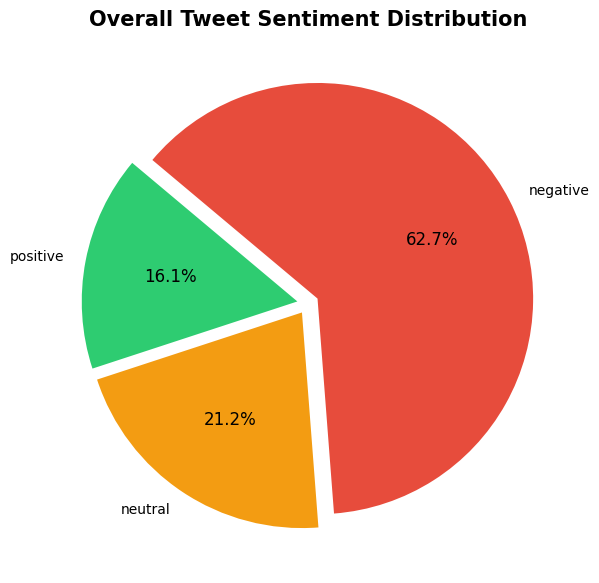

 Chart 1 saved!


In [4]:
sent_pd = spark.sql("""
    SELECT airline_sentiment, COUNT(*) as count
    FROM tweets GROUP BY airline_sentiment
""").toPandas()

colors = {"positive":"#2ecc71","neutral":"#f39c12","negative":"#e74c3c"}
color_list = [colors[s] for s in sent_pd["airline_sentiment"]]

plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    sent_pd["count"],
    labels=sent_pd["airline_sentiment"],
    autopct="%1.1f%%",
    colors=color_list,
    startangle=140,
    explode=[0.05]*len(sent_pd)
)
for text in autotexts:
    text.set_fontsize(12)
plt.title("Overall Tweet Sentiment Distribution", fontsize=15, fontweight="bold")
plt.savefig(r"C:\Users\hp\BIGDATAPROJECT\report\chart1_sentiment_pie.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 1 saved!")

#Chart 2:Sentiment by Airline

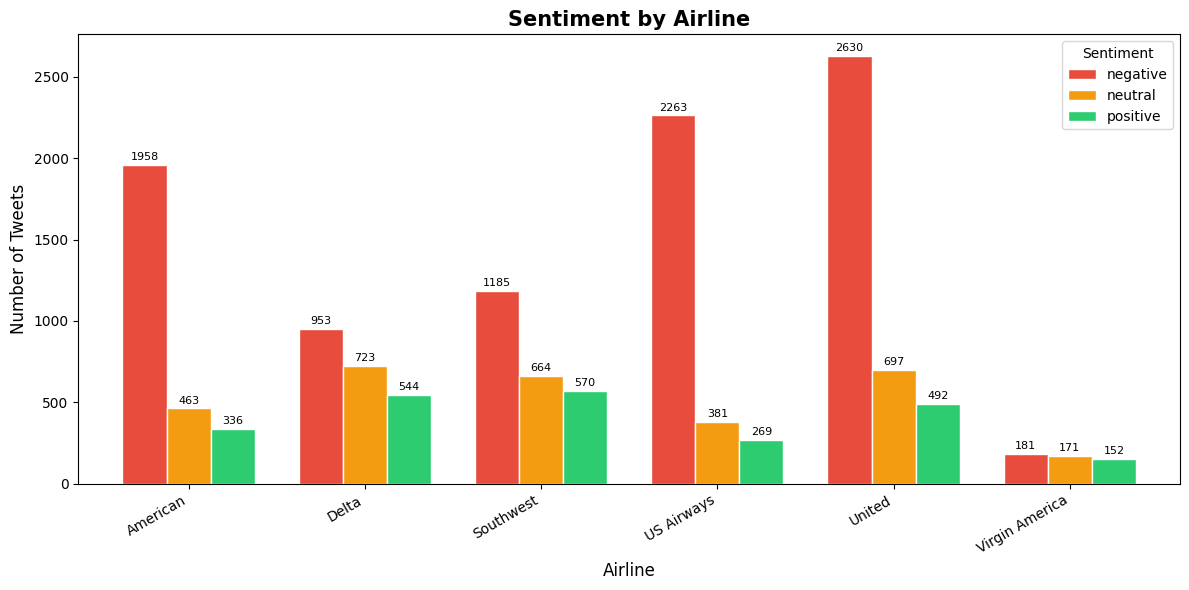

 Chart 2 saved!


In [5]:
airline_pd = spark.sql("""
    SELECT airline, airline_sentiment, COUNT(*) as count
    FROM tweets GROUP BY airline, airline_sentiment
""").toPandas()

pivot = airline_pd.pivot(
    index="airline",
    columns="airline_sentiment",
    values="count"
).fillna(0)

pivot = pivot[["negative","neutral","positive"]]

ax = pivot.plot(
    kind="bar", figsize=(12,6),
    color=["#e74c3c","#f39c12","#2ecc71"],
    edgecolor="white", width=0.75
)
plt.title("Sentiment by Airline", fontsize=15, fontweight="bold")
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment", fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(r"C:\Users\hp\BIGDATAPROJECT\report\chart2_airline_sentiment.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 2 saved!")

#Chart 3:Top Negative Reasons

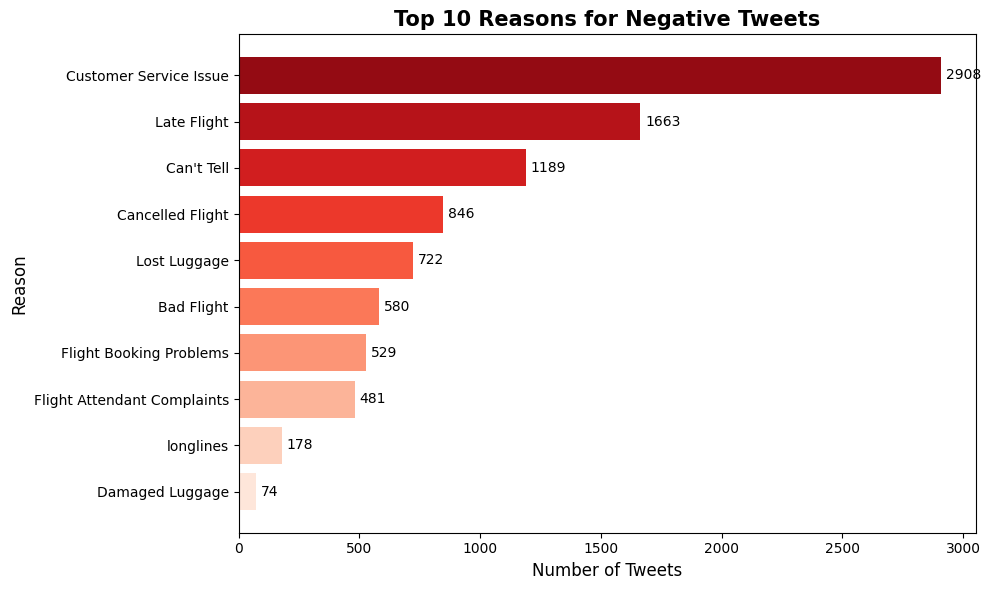

 Chart 3 saved!


In [ ]:
neg_pd = spark.sql("""
    SELECT negativereason, COUNT(*) as count
    FROM tweets
    WHERE airline_sentiment='negative'
    AND negativereason IS NOT NULL
    GROUP BY negativereason
    ORDER BY count DESC
    LIMIT 10
""").toPandas()

plt.figure(figsize=(10,6))
bars = plt.barh(
    neg_pd["negativereason"],
    neg_pd["count"],
    color=sns.color_palette("Reds_r", len(neg_pd))
)

for bar, val in zip(bars, neg_pd["count"]):
    plt.text(bar.get_width() + 20,
             bar.get_y() + bar.get_height()/2,
             str(int(val)), va="center", fontsize=10)

plt.title("Top 10 Reasons for Negative Tweets", fontsize=15, fontweight="bold")
plt.xlabel("Number of Tweets", fontsize=12)
plt.ylabel("Reason", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\BIGDATAPROJECT\report\chart3_negative_reasons.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 3 saved!")

#Chart 4:Heatmap

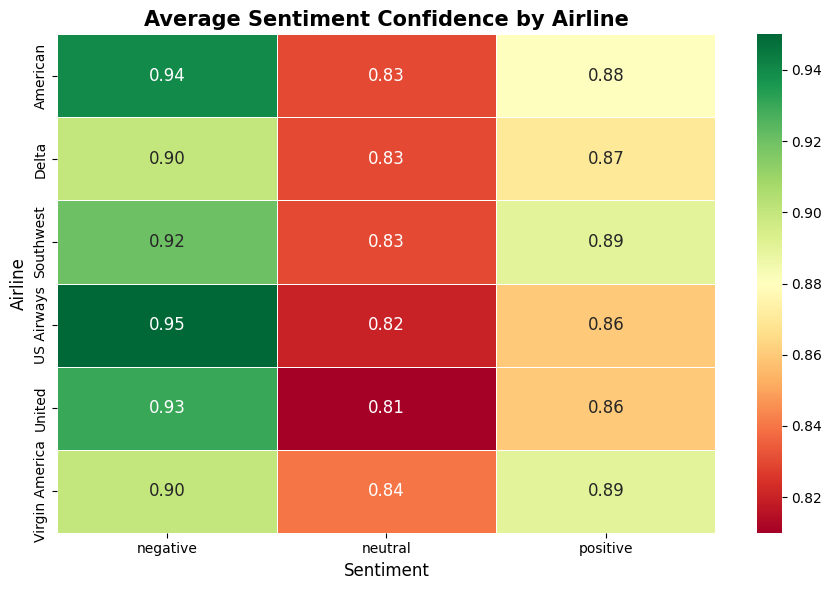

 Chart 4 saved!


In [7]:
conf_pd = spark.sql("""
    SELECT airline, airline_sentiment,
           ROUND(AVG(airline_sentiment_confidence),2) AS avg_conf
    FROM tweets
    GROUP BY airline, airline_sentiment
""").toPandas()

heatmap_data = conf_pd.pivot(
    index="airline",
    columns="airline_sentiment",
    values="avg_conf"
)

plt.figure(figsize=(9,6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f",
    cmap="RdYlGn", linewidths=0.5,
    annot_kws={"size":12}
)
plt.title("Average Sentiment Confidence by Airline",
          fontsize=15, fontweight="bold")
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Airline", fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\hp\BIGDATAPROJECT\report\chart4_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 4 saved!")

#Chart 5:Spark SQL vs MongoDB Performance

C:\Users\hp\AppData\Local\Temp\ipykernel_19276\4130179734.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(r"C:\Users\hp\BIGDATAPROJECT\report\chart5_performance.png",
c:\Users\hp\anaconda3\envs\pyspark_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


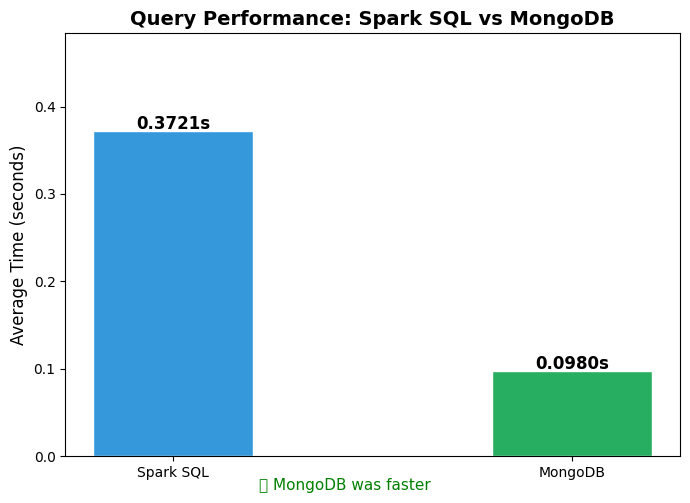

 Chart 5 saved!
   Spark SQL: 0.3721 sec
   MongoDB:   0.0980 sec
   Winner:    MongoDB


In [ ]:
from pymongo import MongoClient
import time

# Spark SQL timing 
times_spark = []
for _ in range(3):
    start = time.time()
    spark.sql("""
        SELECT airline_sentiment, COUNT(*)
        FROM tweets GROUP BY airline_sentiment
    """).collect()
    times_spark.append(time.time() - start)

# MongoDB timing
client = MongoClient("mongodb://localhost:27017/")
collection = client["tweets_db"]["airline_tweets"]

times_mongo = []
for _ in range(3):
    start = time.time()
    list(collection.aggregate([
        {"$group": {"_id": "$airline_sentiment", "count": {"$sum": 1}}}
    ]))
    times_mongo.append(time.time() - start)

avg_spark = round(sum(times_spark)/3, 4)
avg_mongo = round(sum(times_mongo)/3, 4)
winner = "Spark SQL" if avg_spark < avg_mongo else "MongoDB"

# Plot
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(
    ["Spark SQL", "MongoDB"],
    [avg_spark, avg_mongo],
    color=["#3498db","#27ae60"],
    width=0.4, edgecolor="white"
)
for bar, val in zip(bars, [avg_spark, avg_mongo]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{val:.4f}s", ha="center",
            fontsize=12, fontweight="bold")

ax.set_title("Query Performance: Spark SQL vs MongoDB",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Average Time (seconds)", fontsize=12)
ax.set_ylim(0, max(avg_spark, avg_mongo) * 1.3)
plt.figtext(0.5, 0.01, f" {winner} was faster",
            ha="center", fontsize=11, color="green")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\BIGDATAPROJECT\report\chart5_performance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f" Chart 5 saved!")
print(f"   Spark SQL: {avg_spark:.4f} sec")
print(f"   MongoDB:   {avg_mongo:.4f} sec")
print(f"   Winner:    {winner}")

#All Key Insights

In [10]:
print("=" * 50)
print("      KEY INSIGHTS FOR FINAL REPORT")
print("=" * 50)

sent = spark.sql("""
    SELECT airline_sentiment, COUNT(*) as count,
    ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) as pct
    FROM tweets GROUP BY airline_sentiment
    ORDER BY count DESC
""").toPandas()

print("\n📊 SENTIMENT BREAKDOWN:")
for _, row in sent.iterrows():
    print(f"   {row['airline_sentiment']:10} → {int(row['count']):5} tweets ({row['pct']}%)")

print("\n✈️  WORST AIRLINE:  United Airlines (2,630 negative tweets)")
print("✈️  BEST AIRLINE:   Southwest (570 positive tweets)")
print("\n❗ TOP COMPLAINT:  Customer Service Issue (2,883 tweets)")
print("❗ 2ND COMPLAINT:  Late Flight (1,648 tweets)")
print(f"\n⚡ SPARK SQL TIME:  {avg_spark:.4f} sec")
print(f"🍃 MONGODB TIME:   {avg_mongo:.4f} sec")
print(f"🏆 WINNER:         {winner}")


      KEY INSIGHTS FOR FINAL REPORT

 SENTIMENT BREAKDOWN:
   negative   →  9170 tweets (62.7%)
   neutral    →  3099 tweets (21.2%)
   positive   →  2363 tweets (16.1%)

✈️  WORST AIRLINE:  United Airlines (2,630 negative tweets)
✈️  BEST AIRLINE:   Southwest (570 positive tweets)

❗ TOP COMPLAINT:  Customer Service Issue (2,883 tweets)
❗ 2ND COMPLAINT:  Late Flight (1,648 tweets)

⚡ SPARK SQL TIME:  0.3721 sec
🍃 MONGODB TIME:   0.0980 sec
🏆 WINNER:         MongoDB
